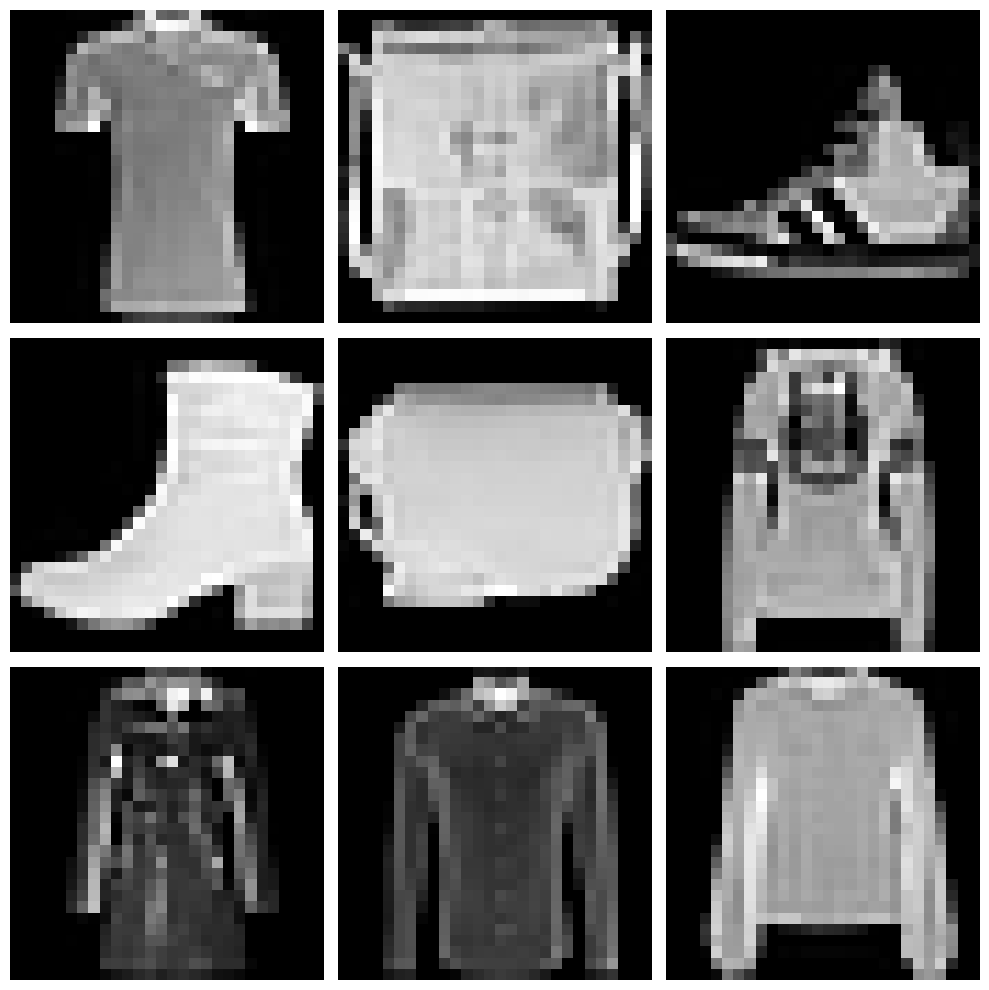

In [16]:
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms

dataset = datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transforms.ToTensor()
)

# torch.manual_seed(41)
indices = torch.randperm(len(dataset))[:9]

fig, axs = plt.subplots(3, 3, figsize=(10, 10))
for i, ax in enumerate(axs.flat):
    img, _ = dataset[indices[i].item()]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.axis("off")
plt.tight_layout()
plt.show()

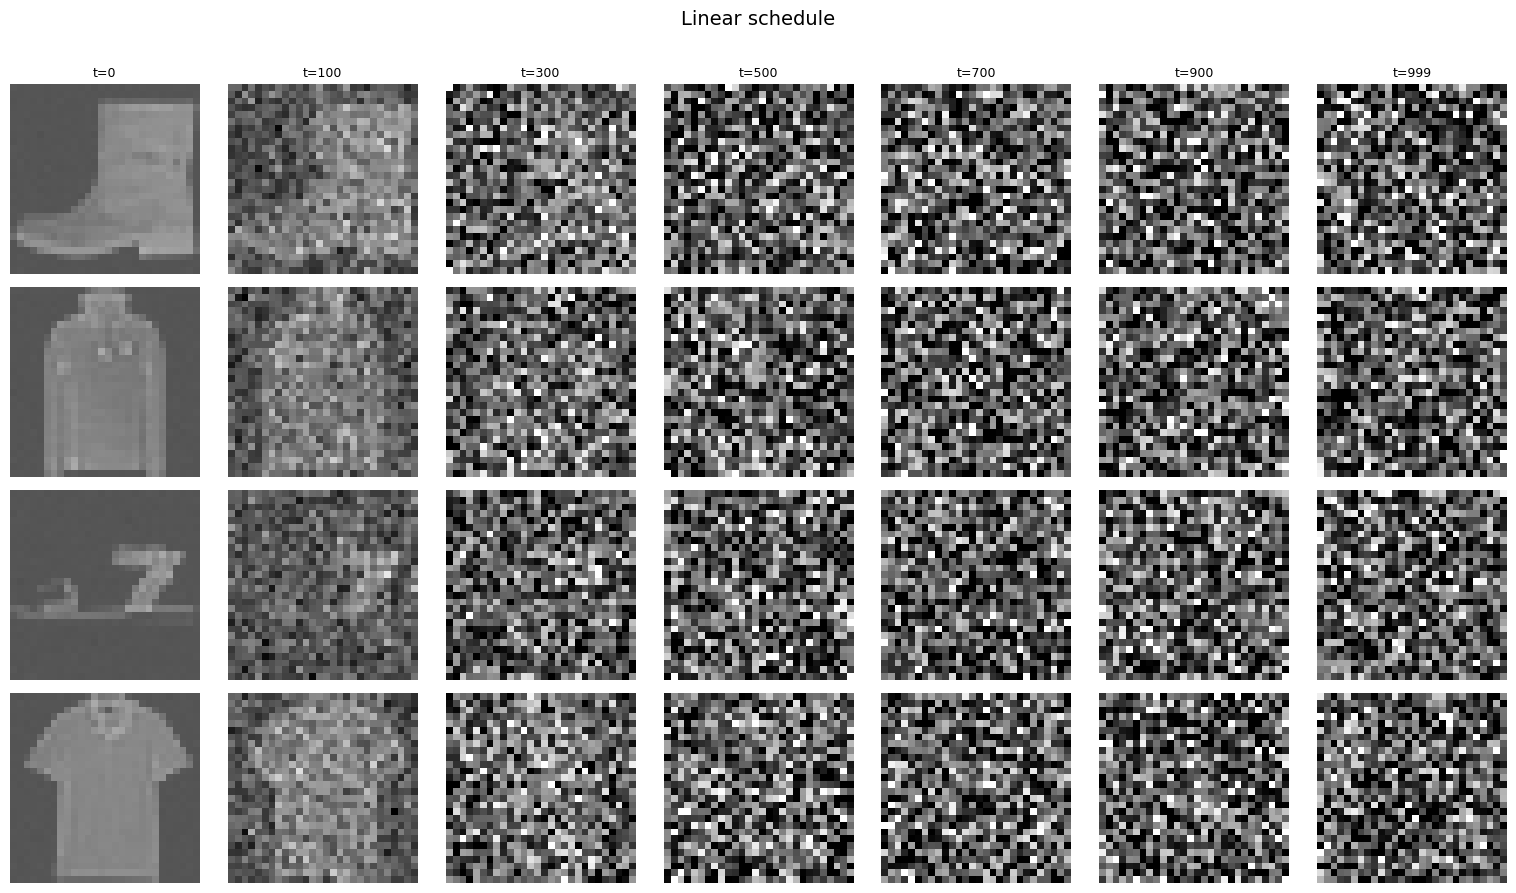

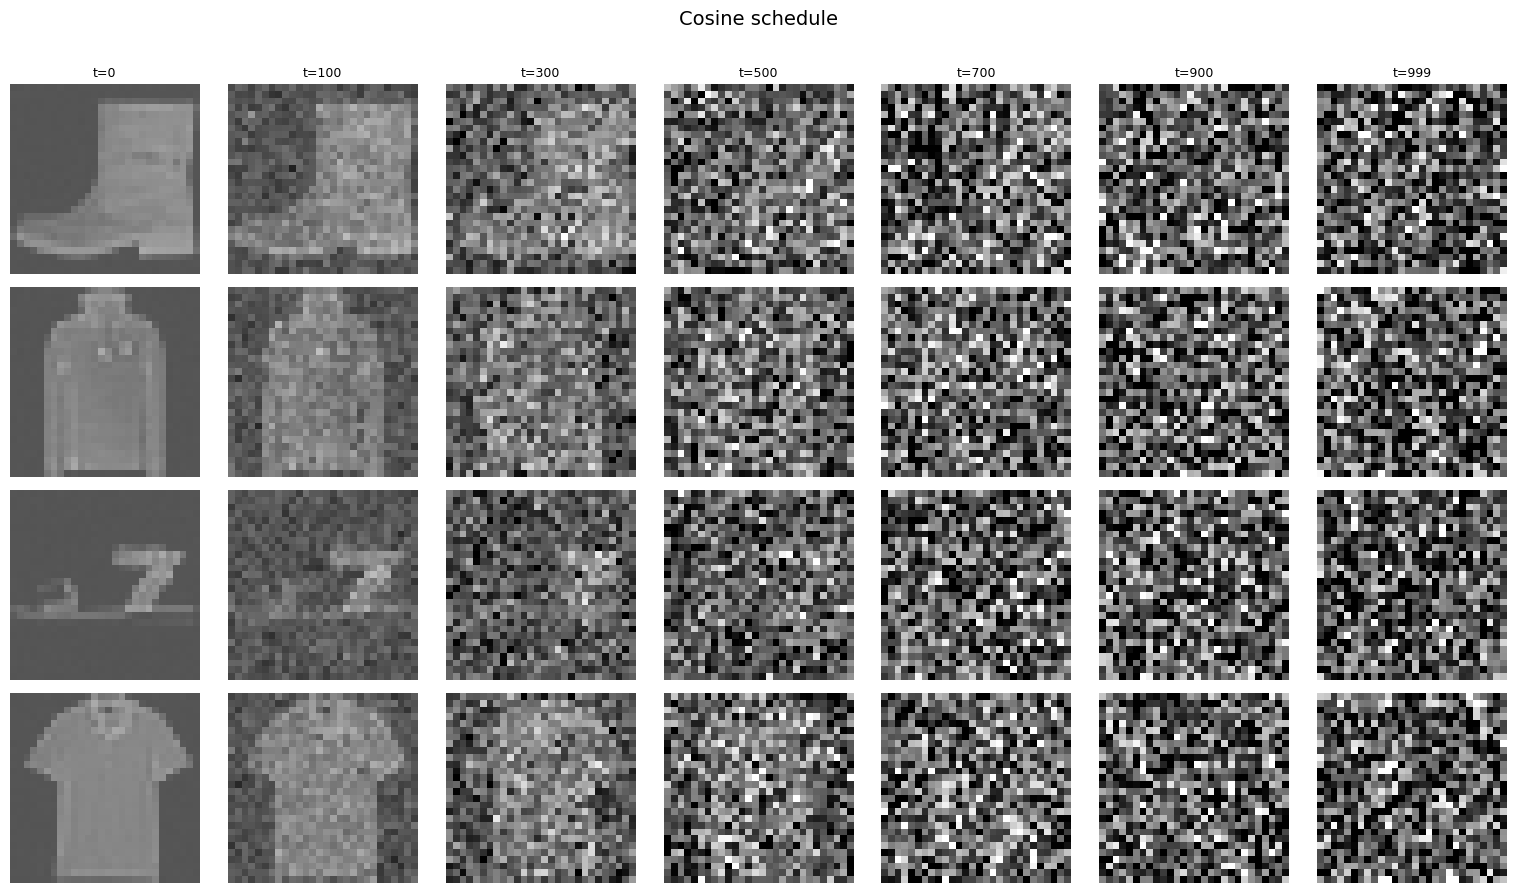

In [17]:
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms

# ── data ──────────────────────────────────────────────────────────────────────
dataset = datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transforms.ToTensor()
)
torch.manual_seed(42)
n_images = 4
indices = torch.randperm(len(dataset))[:n_images]
images = torch.stack([dataset[i.item()][0] for i in indices])  # (4,1,28,28)

# ── noise schedules ───────────────────────────────────────────────────────────
n_steps = 1000

def linear_schedule(n_steps):
    beta = torch.linspace(0.0001, 0.02, n_steps)
    alpha_bar = torch.cumprod(1.0 - beta, dim=0)
    return alpha_bar

def cosine_schedule(n_steps):
    t = torch.arange(n_steps + 1)
    f = torch.cos((t / n_steps + 0.008) / 1.008 * torch.pi / 2) ** 2
    alpha_bar = f / f[0]
    alpha_bar = torch.clamp(alpha_bar[1:], min=1e-5)
    return alpha_bar

schedules = {"Linear schedule": linear_schedule(n_steps),
             "Cosine schedule": cosine_schedule(n_steps)}

timesteps = [0, 100, 300, 500, 700, 900, 999]

# ── plot ──────────────────────────────────────────────────────────────────────
for sched_name, alpha_bar in schedules.items():
    fig, axs = plt.subplots(n_images, len(timesteps),
                            figsize=(2.2 * len(timesteps), 2.2 * n_images))
    fig.suptitle(sched_name, fontsize=14, y=1.01)

    for col, t in enumerate(timesteps):
        ab = alpha_bar[t]
        axs[0, col].set_title(f"t={t}", fontsize=9)
        for row in range(n_images):
            x0 = images[row]
            eps = torch.randn_like(x0)
            xt = ab.sqrt() * x0 + (1 - ab).sqrt() * eps
            axs[row, col].imshow(xt.squeeze().numpy(), cmap="gray", vmin=-1, vmax=2)
            axs[row, col].axis("off")

    plt.tight_layout()
    plt.show()


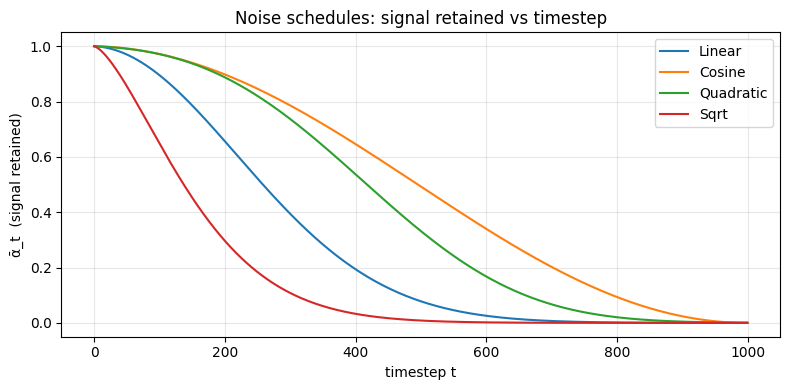

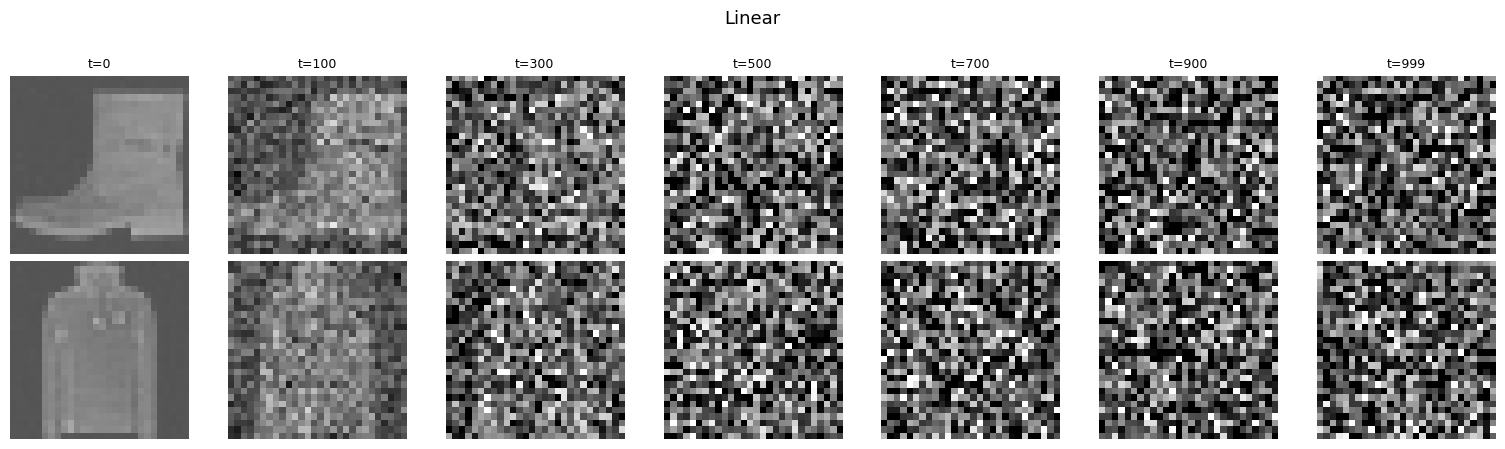

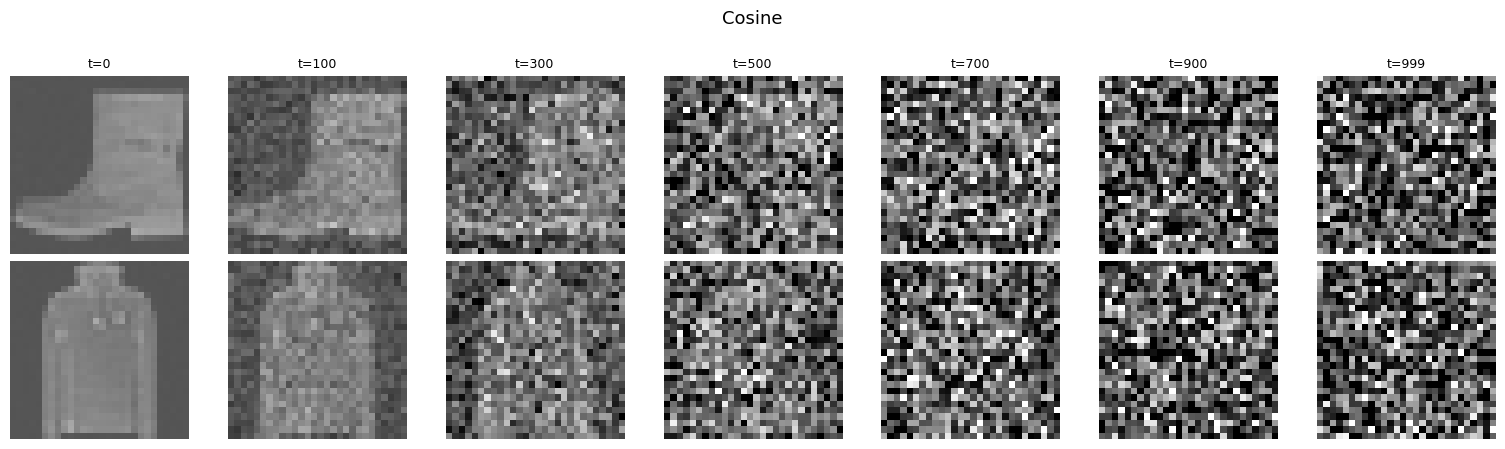

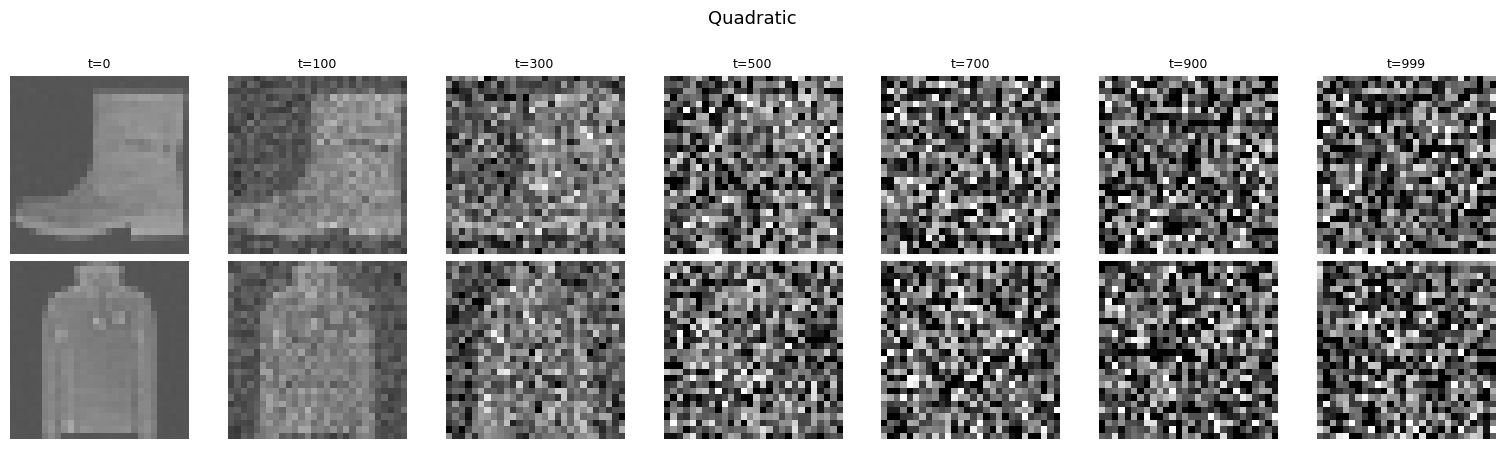

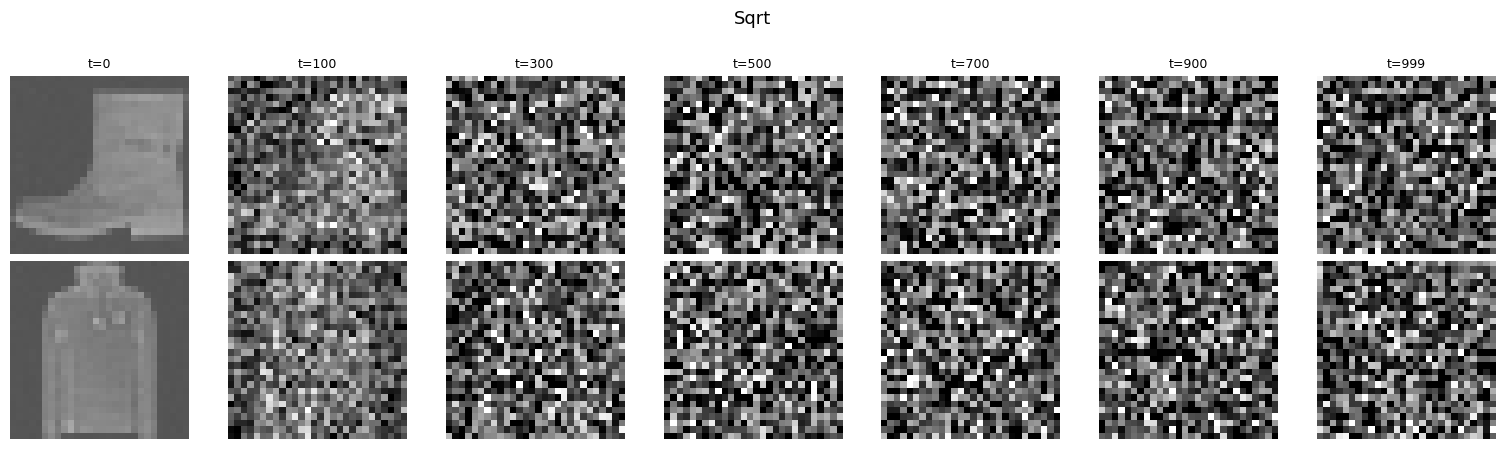

In [19]:
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms

# ── data ──────────────────────────────────────────────────────────────────────
dataset = datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transforms.ToTensor()
)
torch.manual_seed(42)
n_images = 2
indices = torch.randperm(len(dataset))[:n_images]
images = torch.stack([dataset[i.item()][0] for i in indices])

# ── schedules ─────────────────────────────────────────────────────────────────
n_steps = 1000

def linear_alpha_bar(n):
    beta = torch.linspace(0.0001, 0.02, n)
    return torch.cumprod(1.0 - beta, dim=0)

def cosine_alpha_bar(n):
    t = torch.arange(n + 1)
    f = torch.cos((t / n + 0.008) / 1.008 * torch.pi / 2) ** 2
    return torch.clamp(f[1:] / f[0], min=1e-5)

def quadratic_alpha_bar(n):
    # beta grows quadratically — noise concentrates toward end
    beta = torch.linspace(0.0001 ** 0.5, 0.02 ** 0.5, n) ** 2
    return torch.cumprod(1.0 - beta, dim=0)

def sqrt_alpha_bar(n):
    # beta grows as sqrt — noise front-loaded, even more aggressive than linear
    t = torch.linspace(0, 1, n)
    beta = 0.0001 + (0.02 - 0.0001) * t ** 0.5
    return torch.cumprod(1.0 - beta, dim=0)

schedules = {
    "Linear":    linear_alpha_bar(n_steps),
    "Cosine":    cosine_alpha_bar(n_steps),
    "Quadratic": quadratic_alpha_bar(n_steps),
    "Sqrt":      sqrt_alpha_bar(n_steps),
}

# ── 1. alpha_bar curves ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
t_axis = torch.arange(n_steps)
for name, ab in schedules.items():
    ax.plot(t_axis, ab.numpy(), label=name)
ax.set_xlabel("timestep t")
ax.set_ylabel("ᾱ_t  (signal retained)")
ax.set_title("Noise schedules: signal retained vs timestep")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 2. image grids per schedule ───────────────────────────────────────────────
timesteps = [0, 100, 300, 500, 700, 900, 999]

for sched_name, alpha_bar in schedules.items():
    fig, axs = plt.subplots(n_images, len(timesteps),
                            figsize=(2.2 * len(timesteps), 2.2 * n_images))
    fig.suptitle(sched_name, fontsize=13, y=1.01)
    torch.manual_seed(0)
    for col, t in enumerate(timesteps):
        ab = alpha_bar[t]
        axs[0, col].set_title(f"t={t}", fontsize=9)
        for row in range(n_images):
            x0 = images[row]
            eps = torch.randn_like(x0)
            xt = ab.sqrt() * x0 + (1 - ab).sqrt() * eps
            axs[row, col].imshow(xt.squeeze().numpy(), cmap="gray", vmin=-1, vmax=2)
            axs[row, col].axis("off")
    plt.tight_layout()
    plt.show()


## Variable ranges during denoising (reverse process, t: 1000 → 1)

| Variable | Early denoising (high t) | Late denoising (low t) | Range |
|---|---|---|---|
| `t` | 1000 | 1 | 1000 → 1 |
| `beta_t` | 0.02 | 0.0001 | large → small |
| `alpha_t = 1 - beta_t` | 0.98 | 0.9999 | 0.98 → 0.9999 |
| `alpha_bar_t` | ~0 | ~1 | ~0 → ~1 |
| `SNR = alpha_bar_t / (1 - alpha_bar_t)` | ~0 | ~∞ | 0 → ∞ |
| `1 / sqrt(alpha_t)` | ~1.010 | ~1.000 | narrow — nearly constant |
| `beta_t / sqrt(1 - alpha_bar_t)` | small (0.02 / 1 ≈ 0.02) | large (0.0001 / ~0 → ∞) | grows as image clears |
| `sqrt(beta_t)` (stochastic noise term) | 0.141 | 0.010 | large → small |

**Key observations:**
- `alpha_t` barely moves (0.98–0.9999) — its role in the reverse mean is nearly a no-op throughout
- `alpha_bar_t` sweeps the full range — it is the quantity that actually tracks progress
- The stochastic noise term `sqrt(beta_t)` shrinks as denoising progresses, making late steps nearly deterministic
- `beta_t / sqrt(1 - alpha_bar_t)` grows as `alpha_bar_t → 1`, meaning the noise subtraction becomes more aggressive in the final steps relative to the remaining noise
